In [2]:
import numpy as np
import pandas as pd
import matlab.engine
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import seaborn as sns

eng = matlab.engine.start_matlab()

In [3]:
def shell_radii(fractions, R):
    """
    Computes cumulative radii of a multilayer system.
    Model: r_i = R * (x_i)^(1/3)
    where x_i is the cumulative sum of fractions.
    """
    x = np.cumsum(fractions) #cumulative sum
    r = R * np.cbrt(x) #cube root
    return r

def mono_exp(x, TB):
    return 1 - np.exp(-x / TB)  # beta = 1

def fit_mono(df_group, y_label):
    t = df_group["t"].values
    y = df_group[y_label].values 
    popt, _ = curve_fit(mono_exp, t, y, bounds=([0], [np.inf]))
    TB = popt[0]
    yfit = mono_exp(t, *popt)
    return pd.Series({"TB": TB, "yfit": yfit, "R2": r2(y, yfit), "residuals" : y - yfit}) 

def stretched_exp(x, TB, beta):
    return 1 - np.exp(-(x / TB) ** beta)

def fit_stretched(df_group, y_label):
    t = df_group["t"].values
    y = df_group[y_label].values
    popt, _ = curve_fit(stretched_exp, t, y,bounds=([0, 0], [np.inf, np.inf]))
    TB, beta = popt
    yfit = stretched_exp(t, *popt)
    return pd.Series({"TB": TB, "beta" : beta, "yfit": yfit, "R2": r2(y, yfit), "residuals" : y - yfit}) 

def r2(y, yfit):
    ss_res = np.sum((y - yfit) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - ss_res / ss_tot 

R = 0.05 #radius of LNP in um
compounds =  ["mRNA", "C12-200",  "DOPE", "DOTAP"]
distrib = np.array([0.06, 0.63, 0.13, 0.18])

## defining models

In [4]:
rows = []

rows.append((0, 1, 1, 1, 1, 1))

rows.append((1, 1, 1, 0, 0, 0))
rows.append((1, 2, 0, 1, 1, 1))

rows.append((2, 1, 1, 0, 0, 0))
rows.append((2, 2, 0, 1, 0, 0))
rows.append((2, 3, 0, 0, 1, 1))

rows.append((3, 1, 0, 0, 1, 1))
rows.append((3, 2, 0, 1, 0, 0))
rows.append((3, 3, 1, 0, 0, 0))


models = pd.DataFrame(rows, columns=["model", "shell", "mRNA","C12-200", "DOPE", "DOTAP"]).set_index(["model","shell"])
id_models = models.index.get_level_values("model").unique()

In [5]:
models_distrib = models.mul(distrib) #relative volume contributions
# print("total volume :", models_distrib.groupby("model").sum().sum(axis=1))

## start processing data : getting raddi

In [6]:
models_data = pd.DataFrame(0, index=models.index, columns=[])

# store the contribution of each shell
models_data["%"] = models_distrib.sum(axis = 1)
#print("total shell :", models_data["%"].groupby("model").sum())

radii = models_data["%"].groupby("model").transform(lambda s: shell_radii(s, R))

models_data["r_max"] = radii #um
models_data["r_min"] = radii.groupby("model").shift(fill_value=0) #um
models_data["thickness"] = np.round((models_data["r_max"] - models_data["r_min"])*1e3, 3) #nm

radiis = radii.groupby("model").apply(lambda s: np.pad(s, (1,0)))
radiis = radiis.to_frame("radii")

# models_data

## storage for plots : 
* nb of point for a compound in a shell : N = x * A * k
* x : ratio of this compound in the shell
* A : area of the shell
* k : multiplication factor (r_max and r_min are in um not nm, area is reaaaally small)


In [7]:
models_shells = models.div(models.sum(axis=1), axis=0) #relative contribution per shell
# print("nb of shell :", models_shells.groupby("model").sum().sum(axis=1))

In [8]:
area = np.pi * (models_data["r_max"]**2 - models_data["r_min"]**2)  
nb_points = models_shells.loc[models_shells.index, compounds]
k = 1.5e6
nb_points = np.round(nb_points.mul(area, axis=0) * k ).fillna(0).astype(int)    
total_points = nb_points.groupby("model").sum().sum(axis =1)
print(total_points)

rows = []
for model, shell in models.index:
    r_min = models_data.loc[(model, shell), "r_min"]
    r_max = models_data.loc[(model, shell), "r_max"]
    for c in compounds:
        n_points = nb_points.loc[(model, shell), c]
        
        #uniform distribution on the area of the shell
        phi = np.random.uniform(0, 2*np.pi, n_points)
        r = np.sqrt(np.random.uniform(r_min**2, r_max**2, n_points))
        
        # convert from polar to cartesian 
        x = r * np.cos(phi)
        y = r * np.sin(phi)
        for k in range(n_points):
            rows.append((model, shell, c, x[k], y[k]))

#store for drawing later
models_points = pd.DataFrame(rows, columns=["model","shell","compound", "x", "y"])
models_points = models_points.set_index(["model", "shell", "compound"])

model
0    11780
1    11781
2    11782
3    11781
dtype: int64


## spin diffusion simulation

In [9]:
m = 2                 # m=0 for 1D, m=1 for 2D, m=2 for 3D

rstep = 1000          # number of points in space domain
tmax = 100            # maximum time in s
tstep = 200           # number of points in time domain

length_target = R     # length of the target in um
length_source = 0.057 # 0.09  # length of the source in um

epsilon0 = 154 * 2.2      # source enhancement
T1source = 2.3 * 0.5         # source build up time in s
T1target = 4.5 * 0.5        # intrinsic relaxation time of the target in s

Din = 6e-4 # 1.5e-4          # LNP diffusion coefficient based on Viger-Gravel_2018
concX = 130 #117           # 1H concentration in the target in molar
concjuice = 20  #12        # 1H concentration in the source in molar

slope = 60000         # slope of the tanh function
theta = 0.9           # percentage of quenched signal in the source
dep = 0.5             # percentage of depolarization in the source
Cp = 2.54e-2          # Molar heat capacity of 1H spins at 9.4 T Prisco_2021

MAS = 12.5              # MAS rate in kHz
D0 = 4.25e-3          # fictive diffusion coefficient of PS in a static sample: Pinon_thesis

#The source diffusion coeff is scaled with the proton concentration and MAS
Dout = D0*(concjuice/70)**(1/3)/(1+0.6*MAS)

In [10]:
rows = []

for id_model in radiis.index:
    r = radiis.loc[id_model]

    signals = eng.spin_diffusion(
    float(m), float(length_target), float(rstep), float(tmax), float(tstep), 
    float(T1source), float(T1target), float(epsilon0), float(Din), float(Dout),
    float(length_source), float(slope), float(theta), float(dep), float(concjuice), 
    float(concX), float(Cp), matlab.double(r.tolist()))
    
    for i, (s_off, s_on, t) in enumerate( zip(signals["S_off"], signals["S_on"], signals["t"])):
        #m.double (matlab) to np.array
        s_off = np.array(s_off)[0] 
        s_on = np.array(s_on)[0]
        t = np.array(t)[0]    
        for ti, off, on in zip(t, s_off, s_on):
            rows.append({"model" : id_model, "shell": i+1, "t": ti, "S_off": off, "S_on": on})
    print(f"model {id_model} processed")

models_signals = pd.DataFrame(rows)
models_signals = models_signals.set_index(["model", "shell"])

model 0 processed
model 1 processed
model 2 processed
model 3 processed


## observables computation

In [11]:
models_signals["epsilon"]= models_signals["S_on"] / models_signals["S_off"] 
models_signals.loc[models_signals["epsilon"].isna(), "epsilon"] = 0

#recycle time d1 used in experiment -> taking enhancement at that time 
d1 = 5.5 # in s 
models_signals["dist"] = np.abs(models_signals["t"] - d1) 
dist_min = models_signals.sort_values("dist").groupby(["model", "shell"]).head(1) #minimal distance from d1
models_data["epsilon_d1"] = dist_min.sort_index(level=["model", "shell"])["epsilon"]


In [12]:
# normalized S_on for TB fit
S_on_max = models_signals.sort_values("S_on").groupby(["model", "shell"]).tail(1)
models_signals["normS_on"] = models_signals["S_on"]  / S_on_max.sort_index(level=["model", "shell"])["S_on"]

# fitting for having TB 
# mono exponential
fit_m = models_signals.groupby(["model", "shell"]).apply(fit_mono, "normS_on")
models_data["TB_m"] = fit_m["TB"]
models_data["R2_m"] = fit_m["R2"]
models_signals["fit_m"] = fit_m["yfit"].explode()
models_signals["residuals_m"] = fit_m["residuals"].explode()

# # stretched exponential
fit_s = models_signals.groupby(["model", "shell"]).apply(fit_stretched, "normS_on")
models_data["TB_s"] = fit_s["TB"]
models_data["R2_s"] = fit_s["R2"]
models_data["beta"] = fit_s["beta"]
models_signals["fit_s"] = fit_s["yfit"].explode()
models_signals["residuals_s"] = fit_s["residuals"].explode()
models_data


%     r_max     r_min  thickness  epsilon_d1      TB_m  \
model shell                                                              
0     1      1.00  0.050000  0.000000     50.000   62.201604  2.456311   
1     1      0.06  0.019574  0.000000     19.574   51.406646  2.795436   
      2      0.94  0.050000  0.019574     30.426   62.907650  2.437427   
2     1      0.06  0.019574  0.000000     19.574   51.406646  2.795436   
      2      0.63  0.044183  0.019574     24.608   60.013576  2.519299   
      3      0.31  0.050000  0.044183      5.817   68.951984  2.284564   
3     1      0.31  0.033839  0.000000     33.839   55.089475  2.670439   
      2      0.63  0.048979  0.033839     15.140   64.964879  2.383797   
      3      0.06  0.050000  0.048979      1.021   71.118428  2.233695   

                 R2_m      TB_s      R2_s      beta  
model shell                                          
0     1      0.991439  2.560802  0.999847  1.279193  
1     1      0.979381  2.942730  0.999097  1.484317  
      2      0.991945  2.539020  0.999864  1.269236  
2     1      0.979381  2.942730  0.999097  1.484317  
      2      0.989401  2.633416  0.999738  1.317115  
      3      0.995713  2.360448  0.999975  1.187279  
3     1      0.984175  2.804401  0.999428  1.407036  
      2      0.993333  2.476876  0.999909  1.240938  
      3      0.996758  2.300146  0.999989  1.160133

## results : from shell to component

In [13]:
models_compound = models_shells.divide(models_shells.groupby("model").sum()) #relative contribution per compound
# print("number of compound :", models_compound.groupby("model").sum().sum(axis=1))

In [14]:
result = ["epsilon_d1", "TB_m", "TB_s"]

models_result = pd.DataFrame(0.0, 
                            index = pd.MultiIndex.from_product([id_models, compounds], 
                            names=["model", "compound"]), 
                            columns=result)


# using models_compound to have the contribution of each compound 
epsilon_values = models_compound.mul(models_data["epsilon_d1"], axis=0).groupby("model").sum()
epsilon_values = epsilon_values.stack()
models_result["epsilon_d1"] = epsilon_values

TB_m_values = models_compound.mul(models_data["TB_m"], axis=0).groupby("model").sum()
TB_m_values = TB_m_values.stack()
models_result["TB_m"] = TB_m_values

TB_s_values = models_compound.mul(models_data["TB_s"], axis=0).groupby("model").sum()
TB_s_values = TB_s_values.stack()
models_result["TB_s"] = TB_s_values

In [15]:
epsilonsEXP = np.array([52.7, 63.0, 63.0, 63.0])
TBsEXP = np.array([3.0, 2.3, 2.3, 2.3])

data_exp = pd.DataFrame({"epsilon_exp": epsilonsEXP,"TB_exp": TBsEXP,}, index=compounds)
data_exp.index.name = "compound"

# Duplicate for every model
data_exp = pd.concat({m: data_exp for m in id_models},names=["model"])
models_result = models_result.join(data_exp)
models_result

epsilon_d1      TB_m      TB_s  epsilon_exp  TB_exp
model compound                                                     
0     mRNA       62.201604  2.456311  2.560802         52.7     3.0
      C12-200    62.201604  2.456311  2.560802         63.0     2.3
      DOPE       62.201604  2.456311  2.560802         63.0     2.3
      DOTAP      62.201604  2.456311  2.560802         63.0     2.3
1     mRNA       51.406646  2.795436  2.942730         52.7     3.0
      C12-200    62.907650  2.437427  2.539020         63.0     2.3
      DOPE       62.907650  2.437427  2.539020         63.0     2.3
      DOTAP      62.907650  2.437427  2.539020         63.0     2.3
2     mRNA       51.406646  2.795436  2.942730         52.7     3.0
      C12-200    60.013576  2.519299  2.633416         63.0     2.3
      DOPE       68.951984  2.284564  2.360448         63.0     2.3
      DOTAP      68.951984  2.284564  2.360448         63.0     2.3
3     mRNA       71.118428  2.233695  2.300146         52.7     3.0
      C12-200    64.964879  2.383797  2.476876         63.0     2.3
      DOPE       55.089475  2.670439  2.804401         63.0     2.3
      DOTAP      55.089475  2.670439  2.804401         63.0     2.3

## visualization

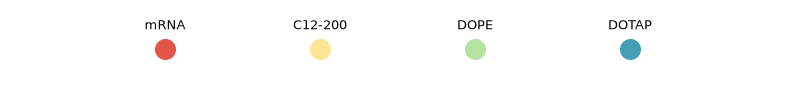

In [16]:
cmap = plt.get_cmap("Spectral")(np.linspace(0.15, 0.95, 10))

compound_colors = {
        "mRNA": cmap[0],
        "C12-200": cmap[3],
        "DOPE":cmap[6],
        "DOTAP":cmap[8],
    } 
fig, ax = plt.subplots(figsize=(10, 1))
for i, (c, color) in enumerate(compound_colors.items()):
    ax.scatter(i, 0, color=color, s=200)
    ax.text(i, 0.5, str(c), ha='center', fontsize=9)
ax.set_xlim(-1, len(compound_colors))
ax.set_ylim(-1, 1)
ax.axis("off")

plt.show()

In [83]:
plt.rcParams.update({
    "font.size": 20,
    "axes.labelsize": 25,
    "axes.titlesize": 20,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 25,
    "figure.titlesize": 20,
})

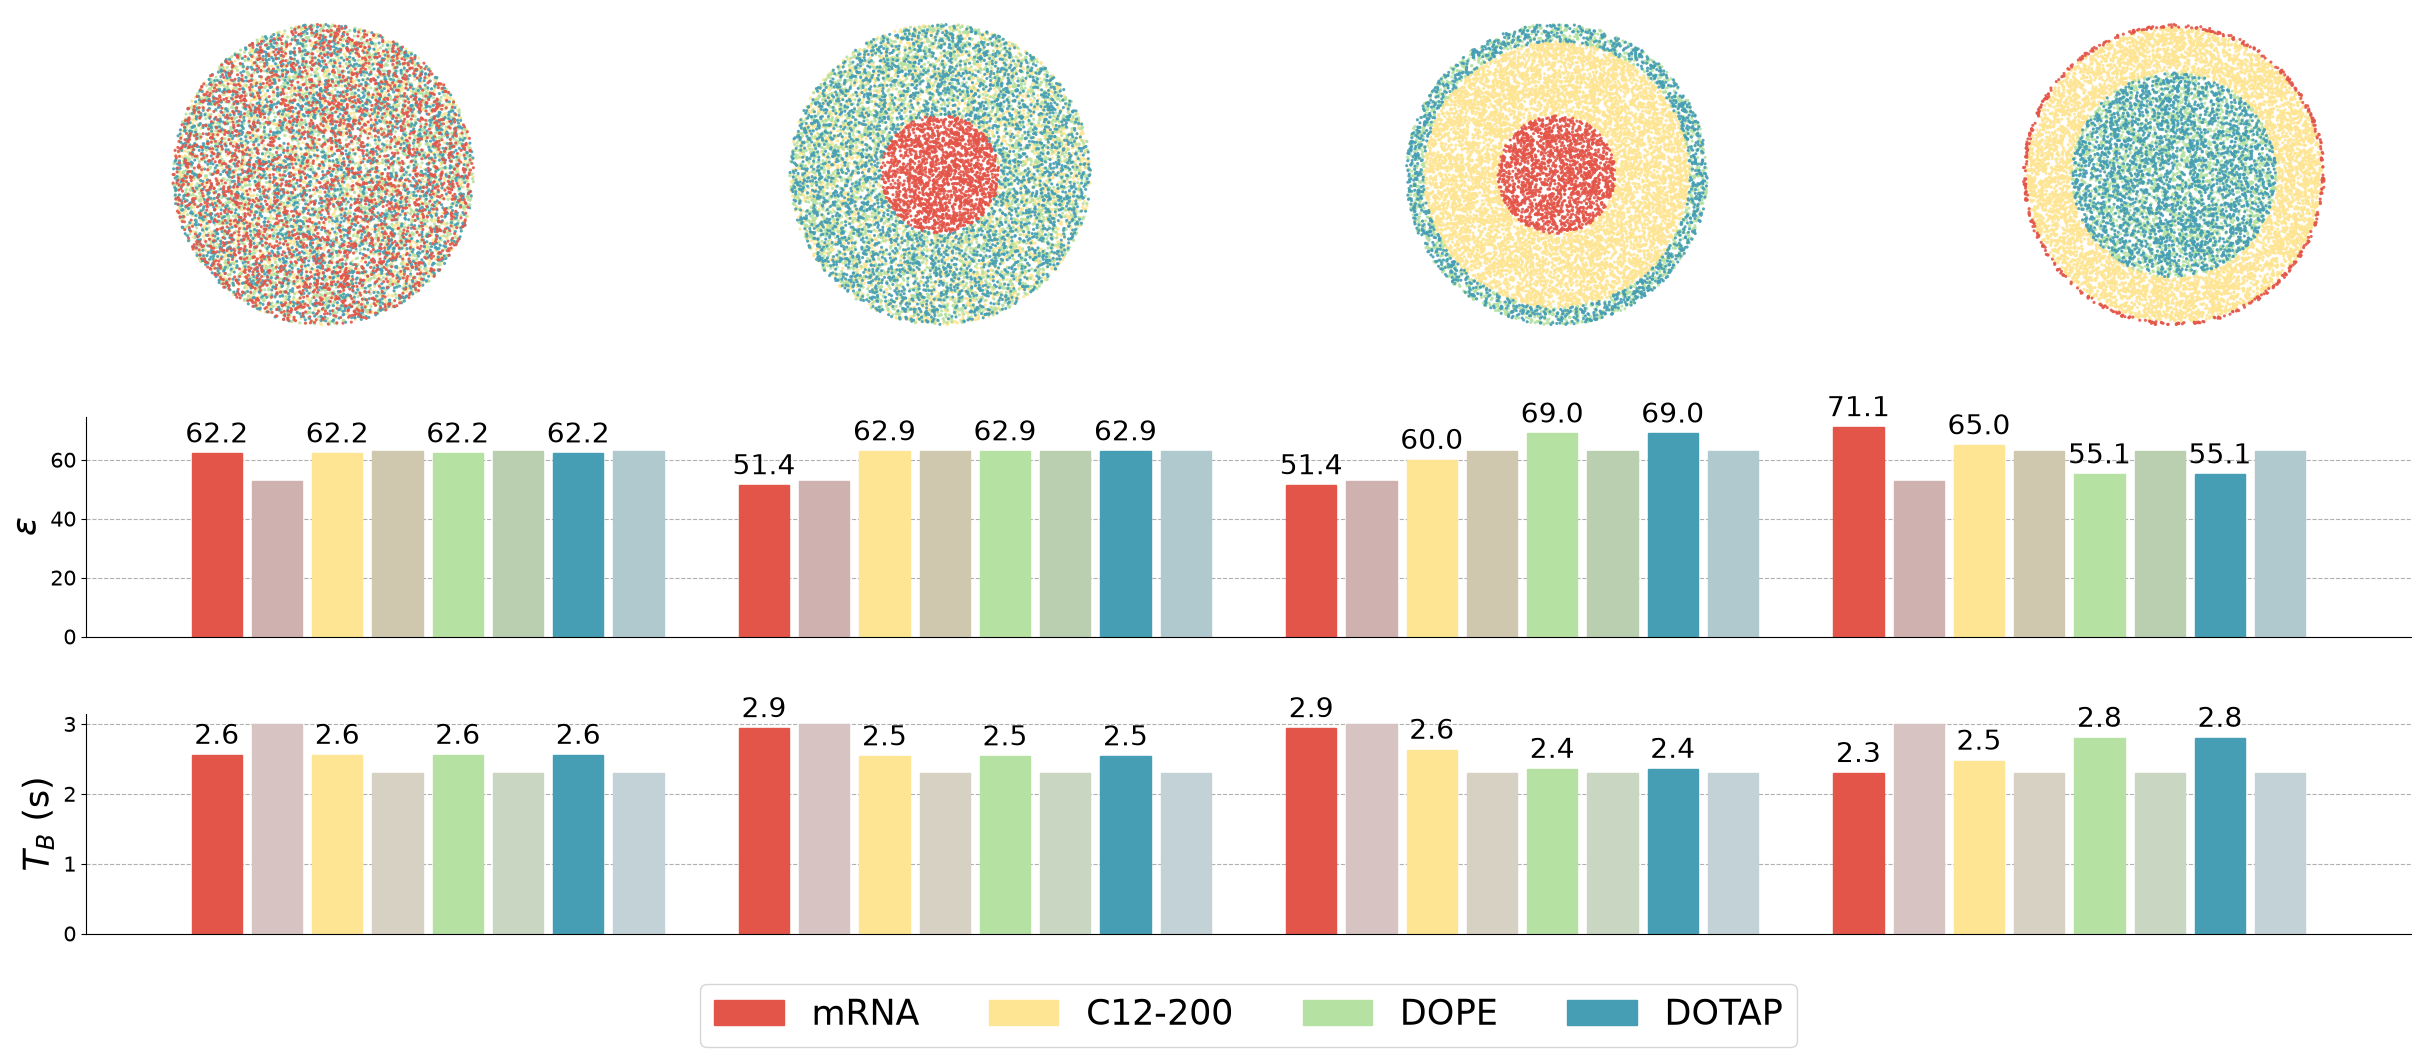

In [84]:
N = len(id_models)
fig = plt.figure(figsize=(30, 12))
gs = fig.add_gridspec(3, N, height_ratios=[3, 2, 2])

axes = {}
for n in range(N):
    base = n
    axes[f"lnp_{n}"] = fig.add_subplot(gs[0, base])
axes[f"epsilon"] = fig.add_subplot(gs[1, :])
axes[f"TB"] = fig.add_subplot(gs[2, :])

for n, (name, model_points) in enumerate(models_points.groupby("model")):
    ax = axes[f"lnp_{n}"]
    for c, compound_points in model_points.groupby("compound"):
        ax.scatter(compound_points["x"], compound_points["y"],s=5, alpha=0.9, edgecolors='none', color = compound_colors[c])
        ax.set_aspect("equal")
        ax.axis('off')


epsilon = models_result["epsilon_d1"].unstack().reindex(columns=compounds)
epsilon_exp = models_result["epsilon_exp"].unstack().reindex(columns=compounds)
epsilon_plot = pd.DataFrame()
for c in compounds:
    epsilon_plot[f"{c} model"] = epsilon[c]
    epsilon_plot[f"{c} exp"] = epsilon_exp[c]
ax1 = axes["epsilon"]
ax1.set_ylabel(r"$\varepsilon$")
ax1.grouped_bar(epsilon_plot, bar_spacing=0.2)
ax1.set_xticks([])
for container, col in zip(ax1.containers, epsilon_plot.columns):
    if "exp" in col:
        color = sns.set_hls_values(compound_colors[compound], l=0.75, s=0.25)
    else:
        compound = col.replace(" model", "")
        color = compound_colors[compound]
        labels = [f"{v:.1f}" if not np.isnan(v) else "" for v in epsilon_plot[col]]
        ax1.bar_label(container, labels=labels, padding=3)
    for bar in container:
        bar.set_color(color)
        

TB = models_result["TB_s"].unstack().reindex(columns=compounds)
TB_exp = models_result["TB_exp"].unstack().reindex(columns=compounds)
TB_plot = pd.DataFrame()
for c in compounds:
    TB_plot[f"{c} model"] = TB[c]
    TB_plot[f"{c} exp"] = TB_exp[c]
ax2 = axes["TB"]
ax2.set_ylabel(r"$T_B$ (s)")
ax2.grouped_bar(TB_plot, bar_spacing=0.2)
ax2.set_xticks([])
for container, col in zip(ax2.containers, TB_plot.columns):
    compound = col.replace(" model", "").replace(" exp", "")
    if "exp" in col: 
        color = sns.set_hls_values(compound_colors[compound], l=0.8, s=0.2)
    else:
        color = compound_colors[compound]
        labels = [f"{v:.1f}" if not np.isnan(v) else "" for v in TB_plot[col]]
        ax2.bar_label(container, labels=labels, padding=3)
    for bar in container:
        bar.set_color(color)

handles, labels = ax2.get_legend_handles_labels()
mapping = {'mRNA model': 'mRNA',
           'C12-200 model' : 'C12-200', 
           'DOPE model' : 'DOPE',
           'DOTAP model': 'DOTAP'}
new_handles = []
new_labels = []

for h, l in zip(handles, labels):
    if l in mapping:
        new_handles.append(h)
        new_labels.append(mapping[l])

labels = [mapping.get(label, label) for label in labels]
ax2.legend(new_handles, new_labels,ncol=len(labels)/2, loc="upper center", bbox_to_anchor=(0.5, -0.15))

for ax in (ax1, ax2):
    ax.grid(True, axis="y", linestyle="--")
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


fig.subplots_adjust(hspace=0.3, wspace = 0.3)
plt.savefig("intership_lnp.png", dpi=150, bbox_inches="tight")
plt.show()

In [85]:
cmap = plt.get_cmap("Spectral")(np.linspace(0.15, 0.95, 2))


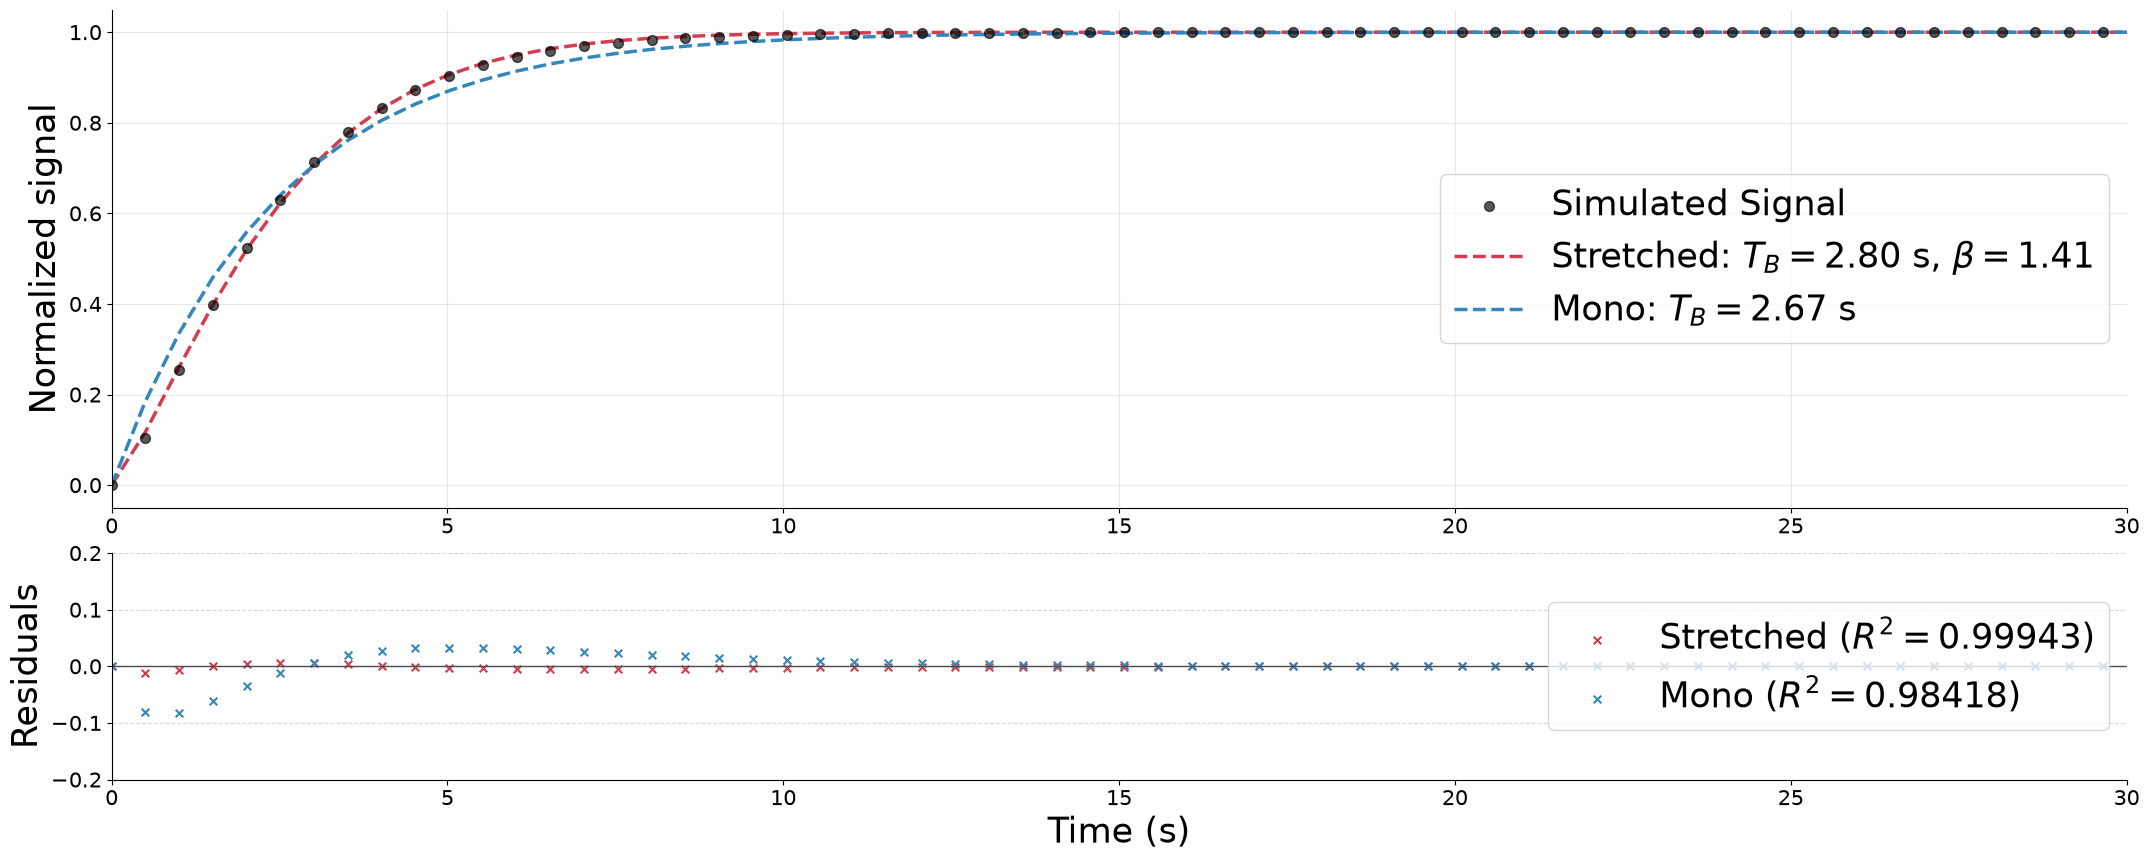

In [86]:
cmap = plt.get_cmap("Spectral")(np.linspace(0.1, 0.9, 2))
colors = {
    "data": "black",
    "stretch": cmap[0],  
    "mono": cmap[1],      
}

signals = models_signals.loc[0]

fig = plt.figure(figsize=(26, 10))

gs = fig.add_gridspec(3, 1, height_ratios=[1, 1, 1])

ax1 = fig.add_subplot(gs[:2, 0])
ax2 = fig.add_subplot(gs[2, 0])

for m, (shell, signal) in enumerate(signals.groupby("shell")):

    t = signal["t"].values
    S = signal["normS_on"].values
    fit_s = signal["fit_s"].values
    fit_m = signal["fit_m"].values
    r_s = signal["residuals_s"].values
    r_m = signal["residuals_m"].values

    R2_s = models_data.loc[(model, shell), "R2_s"]
    R2_m = models_data.loc[(model, shell), "R2_m"]
    beta = models_data.loc[(model, shell), "beta"]
    TB_s = models_data.loc[(model, shell), "TB_s"]
    TB_m = models_data.loc[(model, shell), "TB_m"]

    # Experimental data
    ax1.scatter(t, S, s=50, color=colors["data"], label="Simulated Signal", zorder=3, alpha=0.65)

    # Fits
    ax1.plot(t, fit_s, color=colors["stretch"], lw=2.5, ls="--", label=rf"Stretched: $T_B={TB_s:.2f}$ s, $\beta={beta:.2f}$",)

    ax1.plot(t, fit_m, color=colors["mono"], lw=2.5, ls="--", label=rf"Mono: $T_B={TB_m:.2f}$ s")

    # Residuals
    ax2.scatter(t, r_s, s=30, color=colors["stretch"], marker="x", label=fr"Stretched ($R^2={R2_s:.5f}$)")
    ax2.scatter(t, r_m, s=30, color=colors["mono"], marker="x", label=fr"Mono ($R^2={R2_m:.5f}$)")
    
    ax2.axhline(0, color="0.3", lw=1)

    ax2.set_ylim(-0.2, 0.2)
    ax2.grid(True, axis="y", linestyle="--", alpha=0.5)
    ax1.grid(True, alpha=0.3)

    ax1.set_ylabel("Normalized signal")
    ax2.set_ylabel("Residuals")
    ax2.set_xlabel("Time (s)")

    for ax in (ax1, ax2):
        ax.legend(loc="right")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_xlim(0, 30)

fig.subplots_adjust(hspace=0.2)
fig.savefig("TB.png", dpi=300, bbox_inches="tight")
plt.show()